In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings   # `do not disturbe` mode
warnings.filterwarnings('ignore')

In [ ]:
# Read data from a CSV file
data = pd.read_csv(r"C:\Users\Lenovo\Desktop\ML-亲电性\训练数据表\xyz_rdkitdescriptors.csv")
#cols10 = ['lumo','Charge', 'EV', 'AN', 'EN', 'Density', 'DP', 'AW', 'homo', 'disp',] # 10-Feature
#cols10 = ['disp','homo','lumo','Charge','AN','AW','DP','EV','EN','Density','EN3','EN2','EN1','AN1']
"""cols10 = ["disp", "EN", "ANN", "lumo", "ENN", "BV", "Density",
    "VSA_EState8", "EState_VSA8", "homo", "DP", "VSA_EState9", "EV", 
    "NOCount", "AR", "fr_NH0", "EA", "Charge", "EState_VSA5", "fr_C_S", 
    "fr_C_O", "AW", "AN", "fr_halogen", "NHOHCount", "fr_Ndealkylation2", 
    "fr_ketone", "fr_NH1", "fr_Imine", "fr_methoxy", "fr_nitroso", 
    "fr_NH2", "fr_sulfide", "EState_VSA4", "fr_COO2", "fr_Ndealkylation1", 
    "fr_N_O", "EState_VSA6", "fr_Al_OH", "fr_amidine", "fr_Al_OH_noTert"] """
"""cols10 = [
    "disp", "EN", "BV", "lumo", "ENN", "ANN", "Density", 
    "VSA_EState8", "EState_VSA8", "homo", "VSA_EState9", "NOCount", 
    "EV", "DP", "AR", "EA", "fr_NH0", "Charge", "EState_VSA5", 
    "fr_C_S", "AW", "fr_C_O", "AN", "fr_halogen", "NHOHCount", 
    "fr_Ndealkylation2", "fr_ketone", "fr_NH1", "fr_Imine", 
    "fr_methoxy", "fr_nitroso", "EState_VSA4"
]  """
"""cols10 = [
    "disp", "EN", "lumo", "ANN", "ENN", "BV",  "homo", 
    "Density", "DP", "AR", "fr_NH0", "EV", "EA", "Charge", 
    "NHOHCount", "EState_VSA5", "fr_C_S", "fr_halogen", "AW", 
    "AN", "EState_VSA4"
] """
"""cols10 = [
    "disp", "EN", "lumo", "ANN", "ENN", "BV", "homo", 
    "Density", "DP",  "EV", "Charge", 
    "AW", 
    "AN"
]  """
cols10 = [
    "disp", "EN", "lumo", "ANN", "ENN", "BV", "homo", 
    "Density", "DP", "Charge", "AN"
] 

(633, 11)
Index(['BV', 'disp', 'ANN', 'EN', 'ENN', 'Density', 'lumo', 'DP', 'homo', 'AN',
       'Charge'],
      dtype='object')


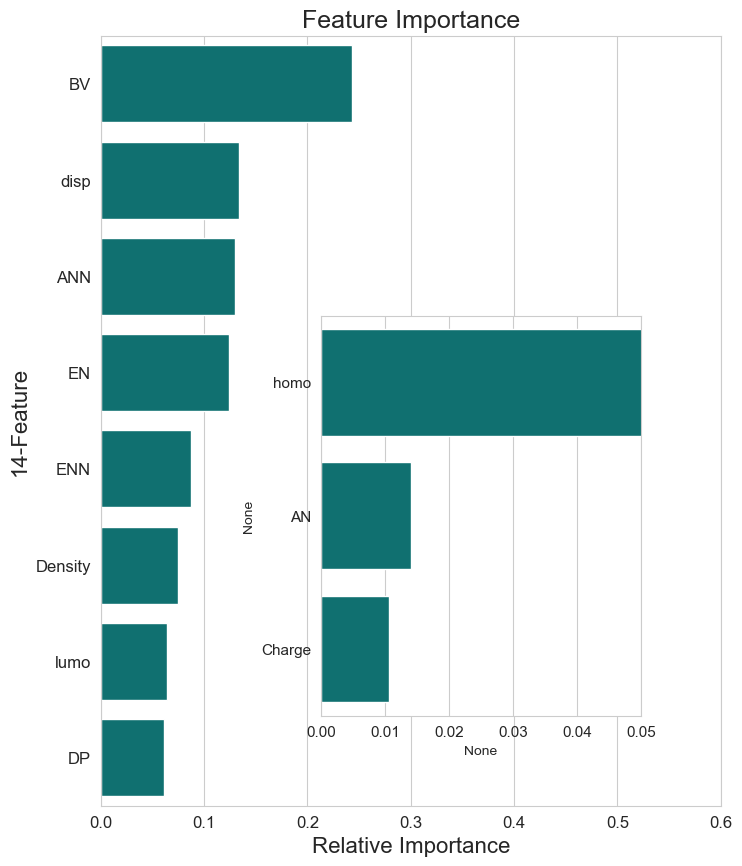

In [ ]:
# Read data
X = data[cols10]
y = data['fKN_def2QZVP']
print(X.shape)

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.1,shuffle=True,random_state=42)
# Create a Random Forest classifier and fit the data.
rf_model = RandomForestRegressor(random_state=42,n_estimators=748,max_depth=237)
rf_model = rf_model.fit(x_train,y_train)

# Calculate feature importance
importances = rf_model.feature_importances_
indices = pd.Series(importances, index=X.columns).sort_values(ascending=False)
cols_14 = indices.index 
#print(indices)


fig, ax = plt.subplots(figsize=(8,10))
ax = sns.barplot(x=indices[:8], y=indices[:8].index, color="teal")
ax.set_title("Feature Importance", fontsize=18)
ax.set_xlabel("Relative Importance", fontsize=16)
ax.set_ylabel("14-Feature", fontsize=16)
ax.tick_params(labelsize=12)
ax.set_xlim([0.0, 0.6])


ax_sub = fig.add_axes([0.4, 0.2, 0.4, 0.4])
sns.barplot(x=indices[8:], y=indices[8:].index, color="teal", ax=ax_sub)
ax_sub.set_xlim([0.0, 0.05])
ax_sub.tick_params(labelsize=11)
print(indices.index)
plt.show()

(633, 11)


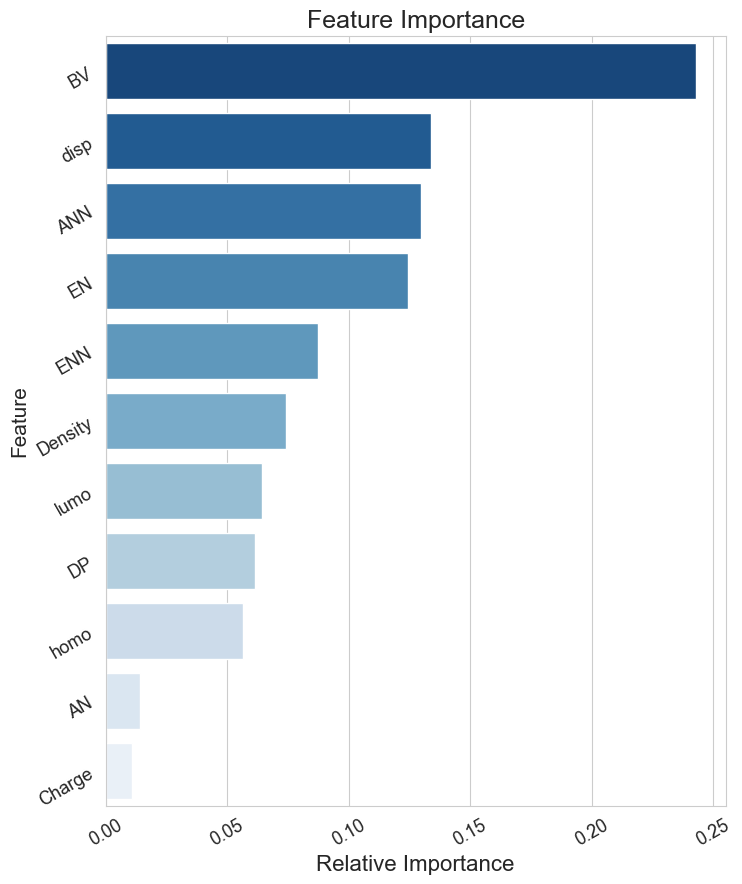

In [ ]:
X = data[cols10]
y = data['fKN_def2QZVP']
print(X.shape)

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.1,shuffle=True,random_state=42)

rf_model = RandomForestRegressor(random_state=42,n_estimators=748,max_depth=237)
rf_model = rf_model.fit(x_train,y_train)


importances = rf_model.feature_importances_
indices = pd.Series(importances, index=X.columns).sort_values(ascending=False)
#print(importances)
#print(indices)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8,10))
ax = sns.barplot(x=indices, y=indices.index, palette="Blues_r")
ax.set_title("Feature Importance", fontsize=18)
ax.set_xlabel("Relative Importance", fontsize=16)
ax.set_ylabel("Feature", fontsize=15)
ax.tick_params(labelsize=13,rotation=30)


plt.show()

(633, 11)


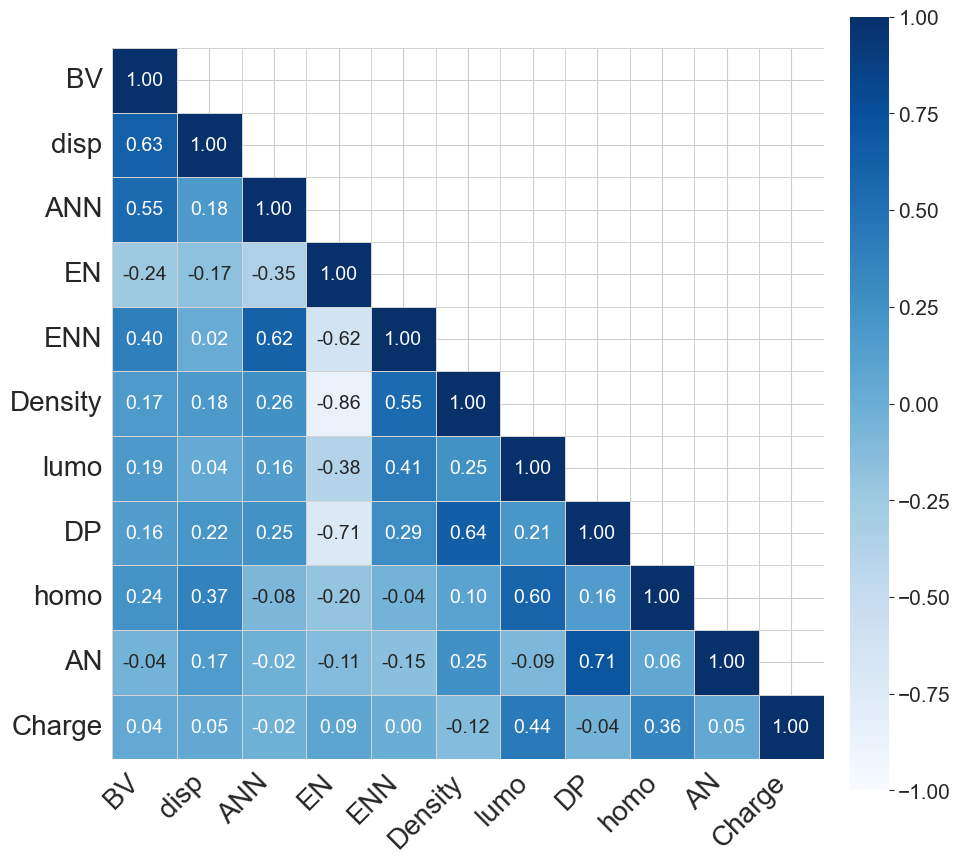

In [ ]:
X = data[cols_14]
y = data['fKN_def2QZVP']
print(X.shape)

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.1,shuffle=True,random_state=42)


matrix = x_train.corr(method='pearson')
#cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True) #色板


mask = np.zeros_like(matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
mask[np.diag_indices_from(mask)] = False  


fig, ax = plt.subplots(figsize=(10, 10))


ax=sns.heatmap(matrix,
               # center=0,           
               annot=True,           
               annot_kws={'size': 14},  
               vmax=1.00,
               vmin=-1.00,
               fmt='.2f',            
               square=True,
               cmap="Blues",         
               mask=mask,             
               linewidths=0.5,        
               linecolor='lightgrey',  
               cbar_kws={'shrink': .82, 'aspect': 20, 'pad': 0.03},
               )


ax.tick_params(labelsize=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)


plt.tight_layout()

plt.show()